# Agricultural Policy Insights

This project uses production, market price, and seed price data to generate useful insights for producers and competent institutions in agricultural policy. The focus is on clear, interpretable questions rather than broad exploratory analysis.

## Core Questions

1. Has the relationship between the seed price and the market price worsened over the years?
2. Does higher yield by region systematically push the selling price down in that year?
3. Can next-season sales price and margin be predicted from historical trends?
4. Which region offers the best net margin per hectare for each crop, and where is it most profitable to plant?

## Presentation Goal

The notebook should support decision-making with a small number of focused, defensible findings that can be presented to stakeholders and aligned with the project guidelines.

In [23]:
import subprocess
import sys
from pathlib import Path
import pandas as pd

DATASET_PATH = Path("data/dataset.csv")
PIPELINE_SCRIPT = Path("scripts/run_pipeline.py")

if not DATASET_PATH.exists():
    print(f"{DATASET_PATH} not found -- running pipeline...")
    result = subprocess.run([sys.executable, str(PIPELINE_SCRIPT)])
    if result.returncode != 0:
        raise RuntimeError("Pipeline failed -- check output above.")
else:
    print(f"{DATASET_PATH} found -- loading directly.")

data\dataset.csv found -- loading directly.


In [24]:
df = pd.read_csv(DATASET_PATH)
df.head()

,Year,Crop,Region,Area (ha),Total production (t),Yield (t/ha),Selling price (RSD/kg),Seed price (RSD/kg)
0,2010,Barley,Belgrade Region,7297.0,23371.0,3.2,15.95,NaN
1,2010,Corn,Belgrade Region,43090.0,259374.0,6.0,16.22,278.43
2,2010,Wheat,Belgrade Region,33256.0,111077.0,3.3,15.46,NaN
3,2010,Barley,Southern and Eastern Serbia Region,22141.0,53382.0,2.4,18.21,NaN
4,2010,Corn,Southern and Eastern Serbia Region,180470.0,952110.0,5.3,16.85,270.65


In [25]:
# Shared setup for the hypothesis cells
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")

analysis_df = df.copy()
for column in ["Selling price (RSD/kg)", "Seed price (RSD/kg)", "Yield (t/ha)", "Area (ha)", "Total production (t)"]:
    analysis_df[column] = pd.to_numeric(analysis_df[column], errors="coerce")

analysis_df["Price margin (RSD/kg)"] = analysis_df["Selling price (RSD/kg)"] - analysis_df["Seed price (RSD/kg)"]
analysis_df["Margin ratio"] = analysis_df["Selling price (RSD/kg)"] / analysis_df["Seed price (RSD/kg)"]

# Seeding rates, used to convert seed price into a cost per hectare figure.
# Corn: 75,000 seeds/ha (3 sowing units), converted with the same 400 g
# thousand-kernel-weight assumption as the RSD/kg conversion above. Wheat
# and barley are sown by weight directly. See README for sources.
SEEDING_RATE_KG_HA = {"Corn": 30, "Wheat": 225, "Barley": 190}

analysis_df["Seeding rate (kg/ha)"] = analysis_df["Crop"].map(SEEDING_RATE_KG_HA)
analysis_df["Seed cost per ha (RSD/ha)"] = analysis_df["Seed price (RSD/kg)"] * analysis_df["Seeding rate (kg/ha)"]
analysis_df["Gross revenue per ha (RSD/ha)"] = analysis_df["Selling price (RSD/kg)"] * analysis_df["Yield (t/ha)"] * 1000
analysis_df["Net margin per ha (RSD/ha)"] = analysis_df["Gross revenue per ha (RSD/ha)"] - analysis_df["Seed cost per ha (RSD/ha)"]

,Year,Crop,Median selling price (RSD/kg),Median seed price (RSD/kg),Median price margin (RSD/kg),Median margin ratio,Median seed cost per ha (RSD/ha)
0,2010,Corn,16.420,271.965,-255.230,0.059536,8158.950
1,2011,Barley,24.050,35.800,-10.520,0.683987,6802.000
2,2011,Corn,22.510,296.010,-275.390,0.075888,8880.300
3,2011,Wheat,25.100,36.610,-11.680,0.680835,8237.250
4,2012,Barley,26.675,37.500,-10.950,0.709482,7125.000
5,2012,Corn,26.755,299.885,-272.260,0.091077,8996.550
6,2012,Wheat,26.740,41.500,-14.235,0.659976,9337.500
7,2013,Barley,26.570,52.425,-25.755,0.510293,9960.750
8,2013,Corn,26.115,388.230,-361.210,0.069992,11646.900
9,2013,Wheat,25.850,54.745,-28.225,0.467040,12317.625


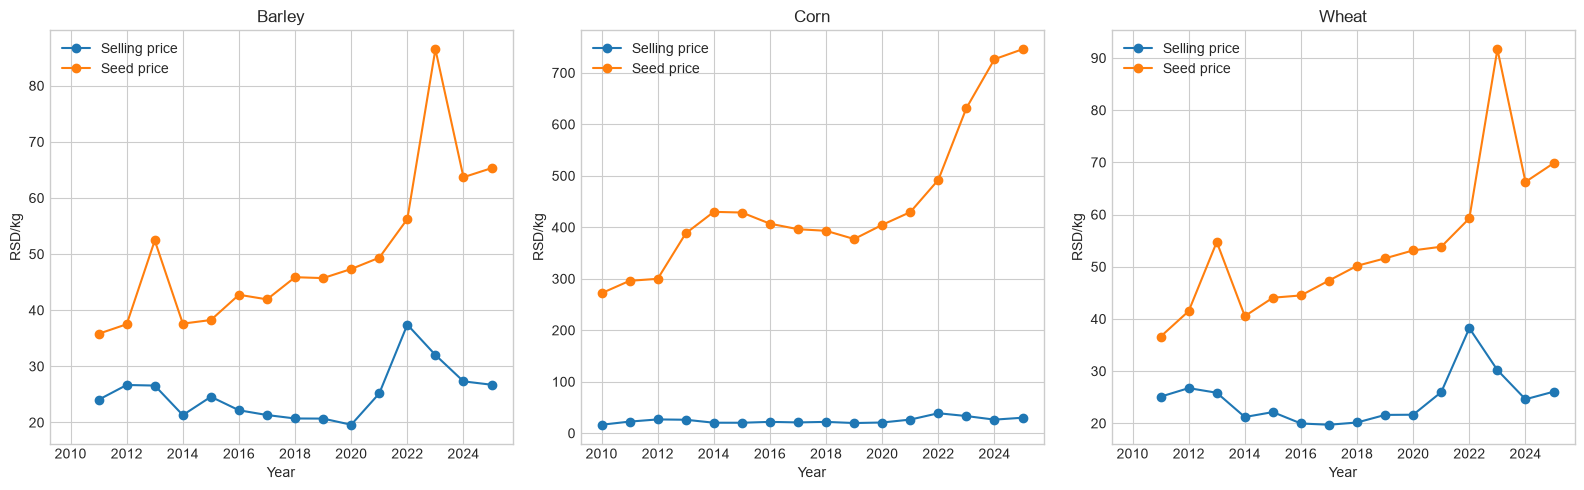

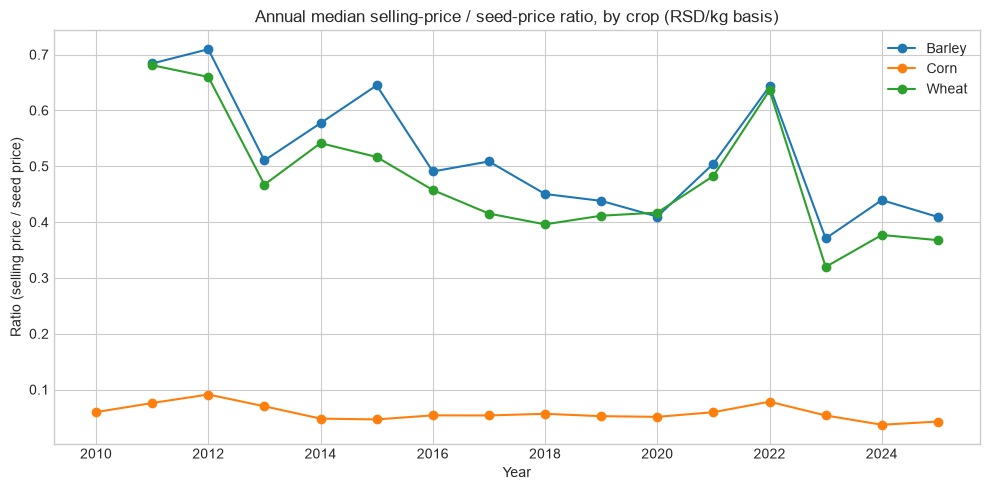

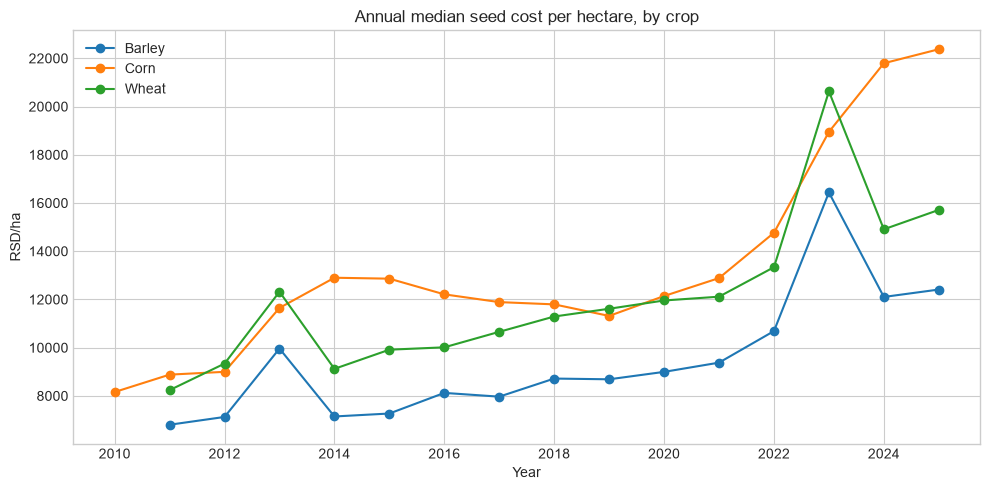

In [26]:
# Hypothesis 1: did the selling-price to seed-price relationship weaken over time?
annual_margin = (
    analysis_df.dropna(subset=["Selling price (RSD/kg)", "Seed price (RSD/kg)"])
    .groupby(["Year", "Crop"])
    .agg(**{
        "Median selling price (RSD/kg)": ("Selling price (RSD/kg)", "median"),
        "Median seed price (RSD/kg)": ("Seed price (RSD/kg)", "median"),
        "Median price margin (RSD/kg)": ("Price margin (RSD/kg)", "median"),
        "Median margin ratio": ("Margin ratio", "median"),
        "Median seed cost per ha (RSD/ha)": ("Seed cost per ha (RSD/ha)", "median"),
    })
    .reset_index()
)
display(annual_margin.head(12))

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True)
for ax, crop in zip(axes, sorted(annual_margin["Crop"].unique())):
    subset = annual_margin[annual_margin["Crop"] == crop]
    ax.plot(subset["Year"], subset["Median selling price (RSD/kg)"], marker="o", label="Selling price")
    ax.plot(subset["Year"], subset["Median seed price (RSD/kg)"], marker="o", label="Seed price")
    ax.set_title(crop)
    ax.set_xlabel("Year")
    ax.set_ylabel("RSD/kg")
    ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
for crop, subset in annual_margin.groupby("Crop"):
    ax.plot(subset["Year"], subset["Median margin ratio"], marker="o", label=crop)
ax.set_title("Annual median selling-price / seed-price ratio, by crop (RSD/kg basis)")
ax.set_xlabel("Year")
ax.set_ylabel("Ratio (selling price / seed price)")
ax.legend()
plt.tight_layout()
plt.show()

# RSD/kg overstates corn's seed burden - corn is sown at a much lower rate (kg/ha) than wheat or barley.
# Seed cost per hectare is a fairer basis.
fig, ax = plt.subplots(figsize=(10, 5))
for crop, subset in annual_margin.groupby("Crop"):
    ax.plot(subset["Year"], subset["Median seed cost per ha (RSD/ha)"], marker="o", label=crop)
ax.set_title("Annual median seed cost per hectare, by crop")
ax.set_xlabel("Year")
ax.set_ylabel("RSD/ha")
ax.legend()
plt.tight_layout()
plt.show()

,Crop,Observations,"Correlation, pooled","Correlation, within year"
1,Corn,64.0,-0.409006,-0.541848
2,Wheat,64.0,0.244398,-0.333003
0,Barley,63.0,0.309271,-0.180003


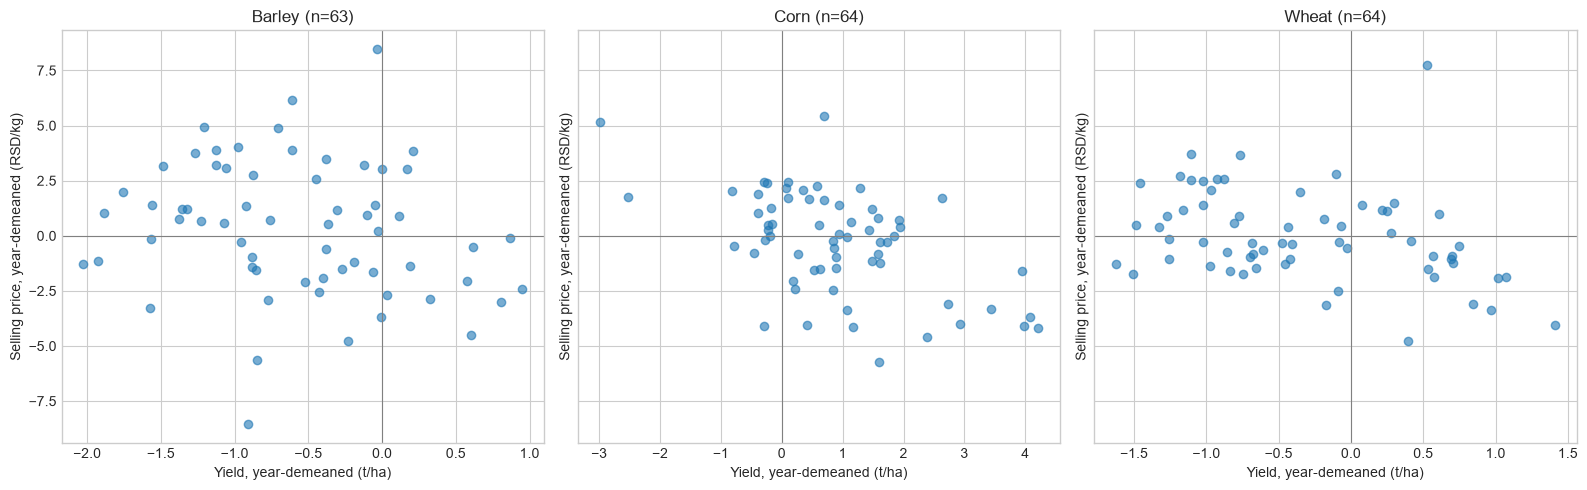

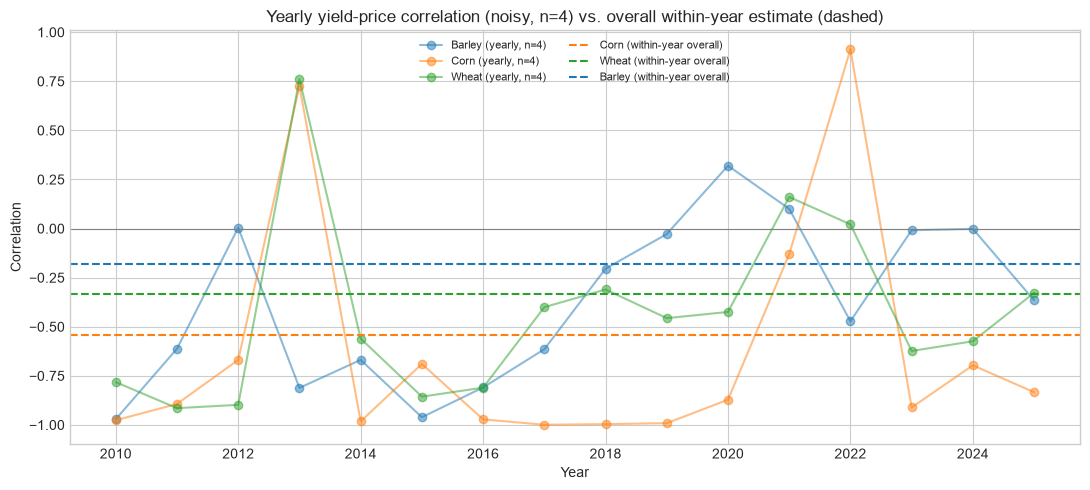

In [27]:
# Hypothesis 2: yield versus selling price, by crop, within each year
# Pooling across years mixes within-year regional variation with across-year
# price trends (inflation, the 2022 shock), which can distort the result.
# Demeaning by year removes that trend while keeping all ~64 points per crop.
demeaned = analysis_df.dropna(subset=["Yield (t/ha)", "Selling price (RSD/kg)"]).copy()
demeaned["Yield, year-demeaned (t/ha)"] = demeaned.groupby("Year")["Yield (t/ha)"].transform(lambda s: s - s.mean())
demeaned["Selling price, year-demeaned (RSD/kg)"] = demeaned.groupby("Year")["Selling price (RSD/kg)"].transform(lambda s: s - s.mean())

yield_price_within_year = (
    demeaned.groupby("Crop")
    .apply(lambda frame: pd.Series({
        "Observations": len(frame),
        "Correlation, pooled": frame["Yield (t/ha)"].corr(frame["Selling price (RSD/kg)"]),
        "Correlation, within year": frame["Yield, year-demeaned (t/ha)"].corr(frame["Selling price, year-demeaned (RSD/kg)"]),
    }))
    .reset_index()
    .sort_values("Correlation, within year")
)
display(yield_price_within_year)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, crop in zip(axes, sorted(demeaned["Crop"].unique())):
    subset = demeaned[demeaned["Crop"] == crop]
    ax.scatter(subset["Yield, year-demeaned (t/ha)"], subset["Selling price, year-demeaned (RSD/kg)"], alpha=0.6)
    ax.axhline(0, color="grey", linewidth=0.8)
    ax.axvline(0, color="grey", linewidth=0.8)
    ax.set_title(f"{crop} (n={len(subset)})")
    ax.set_xlabel("Yield, year-demeaned (t/ha)")
    ax.set_ylabel("Selling price, year-demeaned (RSD/kg)")
plt.tight_layout()
plt.show()

# Supplementary view: yearly correlation (n=4, noisy) alongside the overall
# within-year estimate (dashed), to show the pattern is not a method artifact.
yearly_corr = (
    analysis_df.dropna(subset=["Yield (t/ha)", "Selling price (RSD/kg)"])
    .groupby(["Year", "Crop"])
    .filter(lambda g: len(g) >= 3)
    .groupby(["Year", "Crop"])
    .apply(lambda g: g["Yield (t/ha)"].corr(g["Selling price (RSD/kg)"]))
    .rename("Yearly correlation")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 5))
for crop, subset in yearly_corr.groupby("Crop"):
    ax.plot(subset["Year"], subset["Yearly correlation"], marker="o", alpha=0.5, label=f"{crop} (yearly, n=4)")
overall = dict(zip(yield_price_within_year["Crop"], yield_price_within_year["Correlation, within year"]))
colors = {line.get_label().split(" ")[0]: line.get_color() for line in ax.get_lines()}
for crop, value in overall.items():
    ax.axhline(value, color=colors.get(crop, "black"), linestyle="--", linewidth=1.5,
               label=f"{crop} (within-year overall)")
ax.axhline(0, color="grey", linewidth=0.8)
ax.set_title("Yearly yield-price correlation (noisy, n=4) vs. overall within-year estimate (dashed)")
ax.set_xlabel("Year")
ax.set_ylabel("Correlation")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

,Crop,Region,Forecast year,Predicted selling price (RSD/kg),Predicted margin ratio,History years
0,Barley,Belgrade Region,2026,45.662,0.561357,5
1,Barley,Southern and Eastern Serbia Region,2026,24.865,0.313519,5
2,Barley,Sumadija and Western Serbia Region,2026,31.967,0.387281,5
3,Barley,Vojvodina Region,2026,25.693,0.343119,5
4,Corn,Belgrade Region,2026,30.068,0.035761,5
5,Corn,Southern and Eastern Serbia Region,2026,33.147,0.031079,5
6,Corn,Sumadija and Western Serbia Region,2026,28.299,0.029640,5
7,Corn,Vojvodina Region,2026,23.210,0.017037,5
8,Wheat,Belgrade Region,2026,25.301,0.311521,5
9,Wheat,Southern and Eastern Serbia Region,2026,25.122,0.300739,5


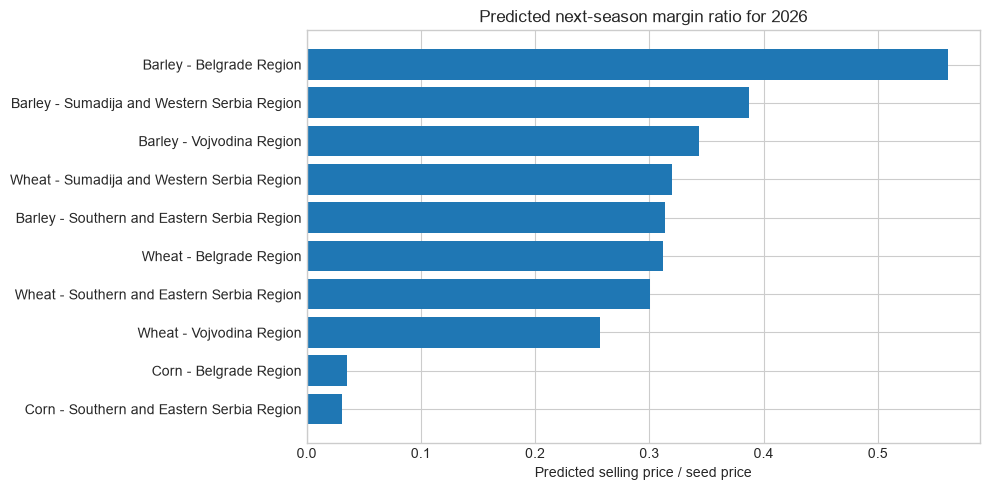

In [28]:
# Hypothesis 3: forecast next-season selling price and margin from trend
forecast_year = int(analysis_df["Year"].max()) + 1
forecast_rows = []

for (crop, region), group in analysis_df.dropna(subset=["Selling price (RSD/kg)", "Margin ratio"]).groupby(["Crop", "Region"]):
    history = group.sort_values("Year").tail(5)
    if len(history) < 3:
        continue

    years = history["Year"].to_numpy(dtype=float)
    price_slope, price_intercept = np.polyfit(years, history["Selling price (RSD/kg)"].to_numpy(dtype=float), 1)
    margin_slope, margin_intercept = np.polyfit(years, history["Margin ratio"].to_numpy(dtype=float), 1)

    forecast_rows.append({
        "Crop": crop,
        "Region": region,
        "Forecast year": forecast_year,
        "Predicted selling price (RSD/kg)": price_slope * forecast_year + price_intercept,
        "Predicted margin ratio": margin_slope * forecast_year + margin_intercept,
        "History years": len(history),
    })

forecast_df = pd.DataFrame(forecast_rows)
display(forecast_df.sort_values(["Crop", "Region"]).head(12))

fig, ax = plt.subplots(figsize=(10, 5))
if not forecast_df.empty:
    plot_forecast = forecast_df.sort_values("Predicted margin ratio", ascending=False).head(10)
    ax.barh(plot_forecast["Crop"].astype(str) + " - " + plot_forecast["Region"].astype(str), plot_forecast["Predicted margin ratio"])
    ax.set_title(f"Predicted next-season margin ratio for {forecast_year}")
    ax.set_xlabel("Predicted selling price / seed price")
    ax.invert_yaxis()
plt.tight_layout()
plt.show()

,Crop,Region,Mean selling price (RSD/kg),Mean yield (t/ha),Mean seed cost per ha (RSD/ha),Observations,Gross revenue per ha (RSD/ha),Net margin per ha (RSD/ha)
2,Barley,Sumadija and Western Serbia Region,28.432667,4.073333,9293.786667,15,115815.728889,106521.942222
0,Corn,Vojvodina Region,21.150625,6.893750,13571.212500,16,145807.121094,132235.908594
1,Wheat,Vojvodina Region,23.716000,5.333333,12226.200000,15,126485.333333,114259.133333


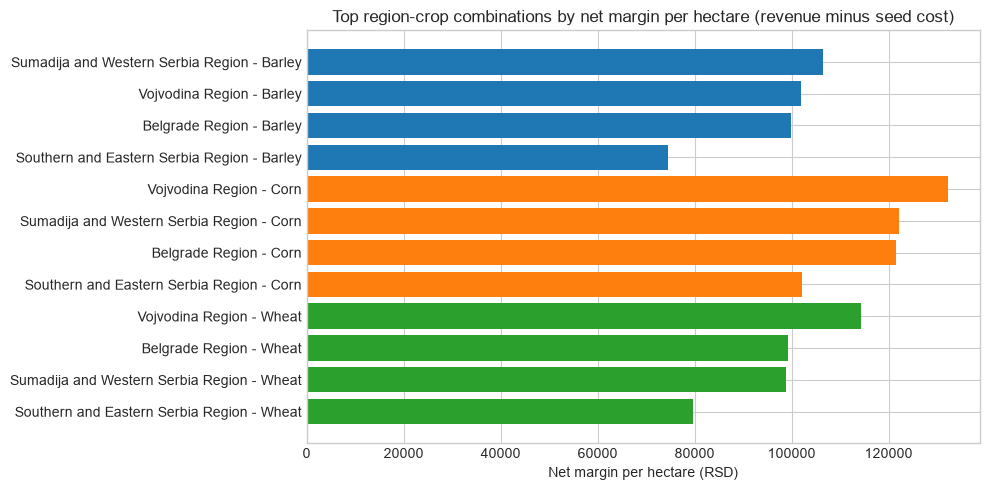

In [ ]:
# Hypothesis 4: region-crop net margin ranking
region_crop_summary = (
    analysis_df.dropna(subset=["Selling price (RSD/kg)", "Yield (t/ha)", "Seed price (RSD/kg)"])
    .groupby(["Crop", "Region"])
    .agg(**{
        "Mean selling price (RSD/kg)": ("Selling price (RSD/kg)", "mean"),
        "Mean yield (t/ha)": ("Yield (t/ha)", "mean"),
        "Mean seed cost per ha (RSD/ha)": ("Seed cost per ha (RSD/ha)", "mean"),
        "Observations": ("Year", "count"),
    })
    .reset_index()
)
region_crop_summary["Gross revenue per ha (RSD/ha)"] = (
    region_crop_summary["Mean selling price (RSD/kg)"] * region_crop_summary["Mean yield (t/ha)"] * 1000
)
region_crop_summary["Net margin per ha (RSD/ha)"] = (
    region_crop_summary["Gross revenue per ha (RSD/ha)"] - region_crop_summary["Mean seed cost per ha (RSD/ha)"]
)

best_region_by_crop = (
    region_crop_summary.sort_values("Net margin per ha (RSD/ha)", ascending=False)
    .groupby("Crop", as_index=False)
    .head(1)
    .reset_index(drop=True)
)
display(best_region_by_crop.sort_values("Crop"))

fig, ax = plt.subplots(figsize=(10, 5))
plot_data = region_crop_summary.sort_values(["Crop", "Net margin per ha (RSD/ha)"], ascending=[True, False]).head(12)
for crop, subset in plot_data.groupby("Crop"):
    ax.barh(subset["Region"] + " - " + crop, subset["Net margin per ha (RSD/ha)"], label=crop)
ax.set_title("Top region-crop combinations by net margin per hectare (revenue minus seed cost)")
ax.set_xlabel("Net margin per hectare (RSD)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Interpretation of the Four Hypotheses

1. **Selling price vs. seed price relationship**\
   All three crops show the same overall direction, the selling-price-to-seed-price
   ratio declined over time, especially after the mid-2010s. That means producers faced a less favorable price relationship in many later years, even though the trend was not perfectly monotonic.
   All three crops also show a shared spike in 2022, likely reflecting the global
   commodity price shock that year, before resuming the downward trend. Corn's seed
   price nearly tripled over the period, a much sharper increase
   than wheat or barley approximatly doubled, which is likely the main driver behind corn's ratio
   reaching its lowest point in 2024-2025. Because corn seed and grain prices operate
   on a very different absolute scale than wheat/barley, each crop is analyzed separately rather than blended into one figure.
   Measured in RSD/kg, corn's seed price looks far more burdensome than wheat's or barley's, but corn is sown at a much lower rate per hectare. Once converted to seed cost per hectare, all three crops sit in a broadly similar range for most of the period, so the RSD/kg comparison alone overstates how much more expensive corn seed actually is to a producer.

2. **Yield vs. selling price**\
   The relationship is tested within each year, since pooling across years would mix
   genuine regional variation with unrelated year-to-year price trends (inflation, the
   2022 shock), which can distort or even flip the sign of the result. After removing
   the yearly trend, all three crops show a negative relationship: corn most strongly
   (-0.54), then wheat (-0.33) and barley (-0.18). This is more economically coherent
   than the simple pooled correlation, which showed a misleading positive relationship
   for wheat and barley driven by the shared trend rather than a true regional effect.
   The pattern also holds up in the noisier year-by-year view (n=4 per year), which
   fluctuates a great deal but averages in the same direction as the within-year estimate for
   each crop, supporting that the negative relationship is real rather than an artifact
   of the demeaning method.

3. **Next-season forecast**\
   A simple historical trend on the last 5 years of data predicts 2026 selling prices and
   margin ratios per crop-region. Corn's predicted margin ratio stays low across all
   regions, consistent with the declining trend in point 1. Wheat and
   barley predictions are more varied by region, but one result stands out: 
   Belgrade Region's barley forecast is far above every other region-crop combination. 
   Belgrade Region has the smallest barley-growing area of
   the four regions, so its 5-year history is thinner and noisier, and a short linear
   trend can extrapolate a recent local swing into an unrealistic forecast. This
   result should be treated as a caution about the forecast's reliability in
   low-volume regions, not as a genuine prediction.

4. **Region-crop net margin ranking**\
   Combining gross revenue per hectare with seed cost per hectare gives a net margin
   figure, still not a full profit measure since fertilizer, pesticide, and labor
   costs are excluded, but a better proxy than gross revenue alone. The strongest
   combinations are corn in Vojvodina, wheat in Vojvodina, and barley in Sumadija and
   Western Serbia, since seed cost differences between regions are small relative to the differences in revenue.
   Corn keeps the highest net margin per hectare of the three crops even after its seed cost is subtracted.

## Policy takeaway

Producer margins have narrowed for all three crops since the early 2010s, most
sharply for corn, whose seed cost has grown much faster than its market price, though
the gap looks smaller once seed cost is measured per hectare rather than per
kilogram. The 2022 price shock offered temporary relief across all crops before the
downward trend resumed. Within a given year, higher-yield regions tend to see
somewhat lower prices for all three crops, a pattern only visible after removing the
shared year-to-year price trend, and the most net-margin-efficient region is
crop-specific (Vojvodina for corn and wheat, Sumadija and Western Serbia for
barley). Forecasts should be read as directional trends rather than precise
predictions, particularly in smaller-production regions where recent history is
thin and volatile.